# Проект: Анализ регрессии и исследование мультиколлинеарности

В данном проекте мы решаем задачу восстановления регрессии на синтетических данных. Основные этапы:
1. Генерация данных с использованием профессиональных инструментов sklearn.
2. Построение ансамблевой модели (Bagging).
3. Оценка качества и диагностика модели (VIF, анализ остатков).

### 1. Подготовка данных

На этом этапе мы генерируем синтетический набор данных. Мы фиксируем `random_state` для обеспечения воспроизводимости результатов и используем `noise` для имитации реальных данных, где зависимости редко бывают идеально линейными.

Для создания данных используем функцию `make_regression`. Это позволяет точно контролировать количество информативных признаков и уровень шума, что делает эксперимент воспроизводимым.

In [7]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_regression

# 1. Генерация данных (используем make_regression для контроля)
# noise=0.5 соответствует изначальному гауссовскому шуму
X, y = make_regression(n_samples=1000, n_features=10, noise=0.5, random_state=42)

feature_names = [f'feature_{i}' for i in range(10)]
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

display(df.head())

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,target
0,1.575876,0.891863,-0.726774,-0.047799,-0.657035,-1.113295,-0.877617,0.994558,-0.299696,-0.761760,-62.799679
1,0.535459,1.266661,-1.779875,1.209010,-0.113158,-0.971062,1.064171,-0.555273,0.741320,-0.987523,108.195671
2,-0.686279,0.157128,0.145836,-1.432671,-0.666849,0.176190,0.585299,0.197917,-0.404362,-0.607472,-115.231935
3,0.925282,0.395914,0.676357,0.168651,1.574147,-0.117172,-0.037687,-0.345907,0.895796,-0.837381,36.931168
4,-0.558922,1.073632,1.565524,0.377212,0.132970,-1.026515,-0.065750,-0.700121,-1.523187,1.195047,131.401728


### 2. Построение и обучение модели

Для решения задачи мы используем **BaggingRegressor**. Бэггинг (Bootstrap Aggregating) помогает снизить риск переобучения путем обучения нескольких базовых моделей на случайных подвыборках данных и последующего усреднения их предсказаний.

Мы применяем `BaggingRegressor`. Хотя для линейной регрессии на чистых данных бэггинг редко дает значительный прирост, в общем случае этот метод эффективно снижает дисперсию (variance) модели.

In [2]:
from sklearn.ensemble import BaggingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Инициализация и обучение модели
base_model = LinearRegression()
bagging_model = BaggingRegressor(estimator=base_model, n_estimators=50, random_state=42)
bagging_model.fit(X_train, y_train)

# Предсказание и оценка
y_pred = bagging_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse:.4f}")
print(f"R^2: {r2:.4f}")

MSE: 0.2326
R^2: 0.9647


### 3. Диагностика: Мультиколлинеарность

Мультиколлинеарность может сделать оценки коэффициентов регрессии неустойчивыми. Мы проверяем это двумя способами:
1. **Корреляционная матрица**: визуальная проверка парных связей.
2. **VIF (Variance Inflation Factor)**: количественная оценка того, насколько сильно дисперсия коэффициента увеличивается из-за корреляции с другими признаками.

Важный этап диагностики — проверка на мультиколлинеарность. Мы используем **VIF (Variance Inflation Factor)**.

*Примечание: Для корректного расчета VIF обязательно добавляется константа (intercept).* Коэффициент корреляции дополняет эту картину, визуализируя связи между парами признаков.

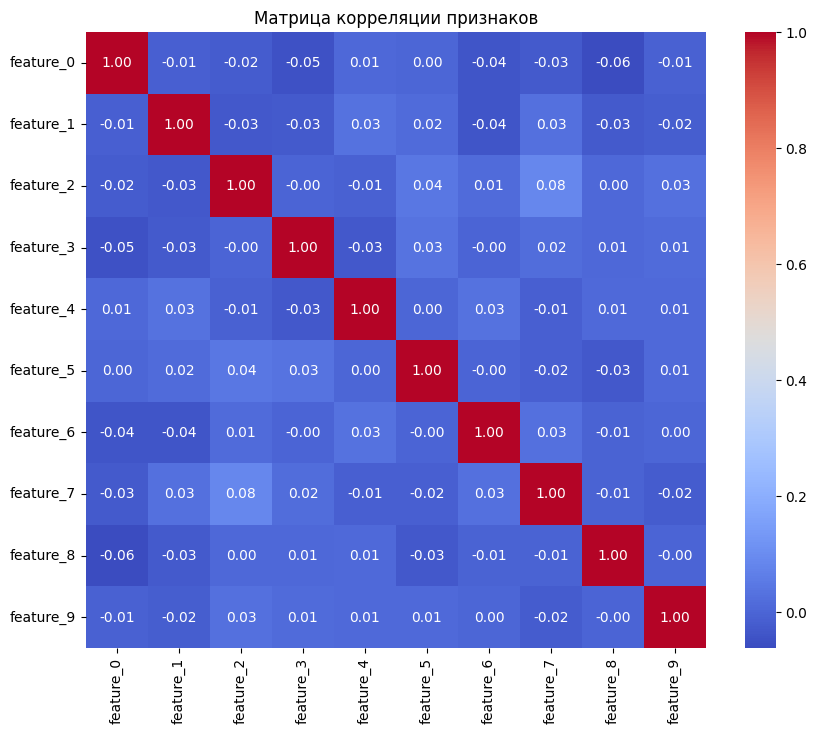

Расчет VIF (с учетом константы):


,Feature,VIF
0,const,1.006726
1,feature_0,1.009430
2,feature_1,1.006437
3,feature_2,1.011819
4,feature_3,1.005733
5,feature_4,1.003401
6,feature_5,1.005055
7,feature_6,1.004984
8,feature_7,1.010759
9,feature_8,1.005990


In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Корреляционная матрица
plt.figure(figsize=(10, 8))
sns.heatmap(df[feature_names].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Матрица корреляции признаков')
plt.show()

# Улучшенный анализ мультиколлинеарности
# Добавляем константу (intercept) для корректного расчета VIF
X_with_const = sm.add_constant(df[feature_names])

vif_data = pd.DataFrame()
vif_data["Feature"] = X_with_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_with_const.values, i) for i in range(X_with_const.shape[1])]

print("Расчет VIF (с учетом константы):")
display(vif_data)

### 4. Оценка качества и анализ остатков

Финальный этап — проверка адекватности модели через анализ ошибок (остатков). В идеальной модели остатки должны иметь нормальное распределение и не иметь видимых закономерностей.

Анализ остатков позволяет проверить адекватность модели:
* Если остатки распределены случайно — модель работает корректно.
* Гистограмма помогает убедиться в нормальности распределения ошибок.
* График важности признаков показывает вклад каждой переменной в итоговое предсказание.

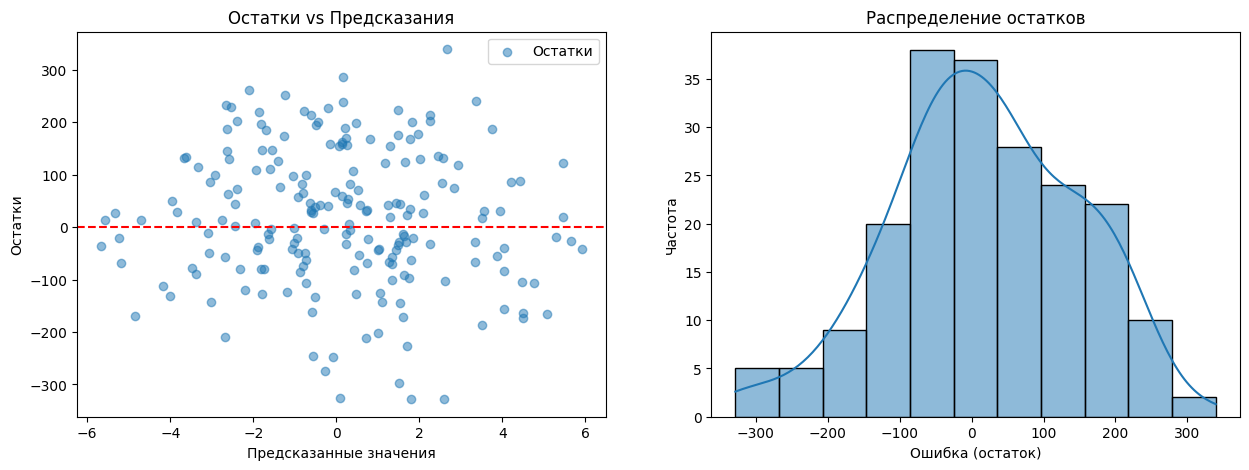

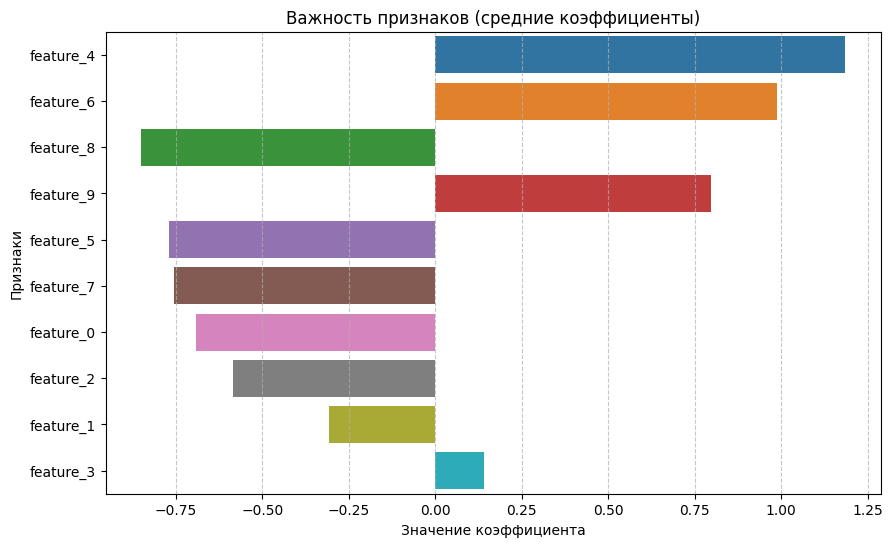

In [9]:
residuals = y_test - y_pred

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# График остатков
ax[0].scatter(y_pred, residuals, alpha=0.5, label='Остатки')
ax[0].axhline(0, color='red', linestyle='--')
ax[0].set_xlabel('Предсказанные значения')
ax[0].set_ylabel('Остатки')
ax[0].set_title('Остатки vs Предсказания')
ax[0].legend()

# Распределение остатков
sns.histplot(residuals, kde=True, ax=ax[1])
ax[1].set_xlabel('Ошибка (остаток)')
ax[1].set_ylabel('Частота')
ax[1].set_title('Распределение остатков')

plt.show()

# Важность признаков (средние коэффициенты по бэггингу)
avg_coef = np.mean([est.coef_ for est in bagging_model.estimators_], axis=0)
importance_df = pd.DataFrame({'feature': feature_names, 'coefficient': avg_coef})
importance_df = importance_df.reindex(importance_df['coefficient'].abs().sort_values(ascending=False).index)

plt.figure(figsize=(10, 6))
sns.barplot(x='coefficient', y='feature', data=importance_df, hue='feature', legend=False)
plt.title('Важность признаков (средние коэффициенты)')
plt.xlabel('Значение коэффициента')
plt.ylabel('Признаки')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()